In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

In [293]:
df = pd.read_csv("hotel_booking.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [294]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [295]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [296]:
df.shape

(119390, 36)

In [297]:
columns_to_drop = [
    'name', 
    'email', 
    'phone-number', 
    'credit_card', 
    'agent', 
    'company', 
    'reservation_status', 
    'reservation_status_date',
    'arrival_date_year',         # Maine pehle bataya tha, 2015-2017 ka data 2026 mein kaam nahi aayega
    'arrival_date_week_number',   # Jab hamare paas Month aur Day hai, toh week number ki zaroorat nahi hai
    'assigned_room_type',         # Yeh room booking ke baad (check-in par) assign hota hai, cancellation pehle hoti hai! (Data Leakage)
    'reservation_status',         # (Agar pehle drop nahi kiya toh) isme 'Check-Out' likha hota hai, direct cheat-code hai model ke liye
    'reservation_status_date' 
]

df = df.drop(columns_to_drop, axis=1)
df.head()

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,July,1,0,0,2,0.0,0,...,0,0,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,0,737,July,1,0,0,2,0.0,0,...,0,0,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel,0,7,July,1,0,1,1,0.0,0,...,0,0,A,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel,0,13,July,1,0,1,1,0.0,0,...,0,0,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel,0,14,July,1,0,2,2,0.0,0,...,0,0,A,0,No Deposit,0,Transient,98.0,0,1


In [298]:
df.shape

(119390, 25)

In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_month              119390 non-null  object 
 4   arrival_date_day_of_month       119390 non-null  int64  
 5   stays_in_weekend_nights         119390 non-null  int64  
 6   stays_in_week_nights            119390 non-null  int64  
 7   adults                          119390 non-null  int64  
 8   children                        119386 non-null  float64
 9   babies                          119390 non-null  int64  
 10  meal                            119390 non-null  object 
 11  country                         118902 non-null  object 
 12  market_segment  

In [300]:
df.duplicated().sum()

np.int64(33273)

In [301]:
df.drop_duplicates(inplace=True)

In [302]:
df.duplicated().sum()

np.int64(0)

In [303]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,July,1,0,0,2,0.0,0,...,0,0,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,0,737,July,1,0,0,2,0.0,0,...,0,0,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel,0,7,July,1,0,1,1,0.0,0,...,0,0,A,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel,0,13,July,1,0,1,1,0.0,0,...,0,0,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel,0,14,July,1,0,2,2,0.0,0,...,0,0,A,0,No Deposit,0,Transient,98.0,0,1


In [304]:
df.shape

(86117, 25)

In [305]:
df.isnull().sum()

hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_month                  0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                            4
babies                              0
meal                                0
country                           450
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
booking_changes                     0
deposit_type                        0
days_in_waiting_list                0
customer_type                       0
adr                                 0
required_car_parking_spaces         0
total_of_special_requests           0
dtype: int64

In [306]:
df["country"].unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', nan, 'ROU', 'NOR', 'OMN',
       'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
       'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
       'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
       'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
       'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
       'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
       'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
       'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
       'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
       'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
       'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
       'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
       'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
       'KNA', 'E

In [307]:
df["children"].fillna(0, inplace=True)

In [308]:
df["country"].fillna("Others", inplace=True)
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_month                0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64

In [309]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,July,1,0,0,2,0.0,0,...,0,0,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,0,737,July,1,0,0,2,0.0,0,...,0,0,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel,0,7,July,1,0,1,1,0.0,0,...,0,0,A,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel,0,13,July,1,0,1,1,0.0,0,...,0,0,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel,0,14,July,1,0,2,2,0.0,0,...,0,0,A,0,No Deposit,0,Transient,98.0,0,1


In [310]:
df["country"].unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', 'Others', 'ROU', 'NOR',
       'OMN', 'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA',
       'NLD', 'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN',
       'MOZ', 'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR',
       'UKR', 'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU',
       'TUR', 'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA',
       'KOR', 'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN',
       'GEO', 'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY',
       'KWT', 'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN',
       'LBN', 'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM',
       'MKD', 'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS',
       'COM', 'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI',
       'SAU', 'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU',
       'MDG', 'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI',
       'STP', 'KNA

In [311]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_month                0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64

C:\Users\Amir sohail\AppData\Local\Temp\ipykernel_3736\1507436652.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='hotel', y='is_canceled', data=df, palette='Blues_d', ci=None)
C:\Users\Amir sohail\AppData\Local\Temp\ipykernel_3736\1507436652.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hotel', y='is_canceled', data=df, palette='Blues_d', ci=None)


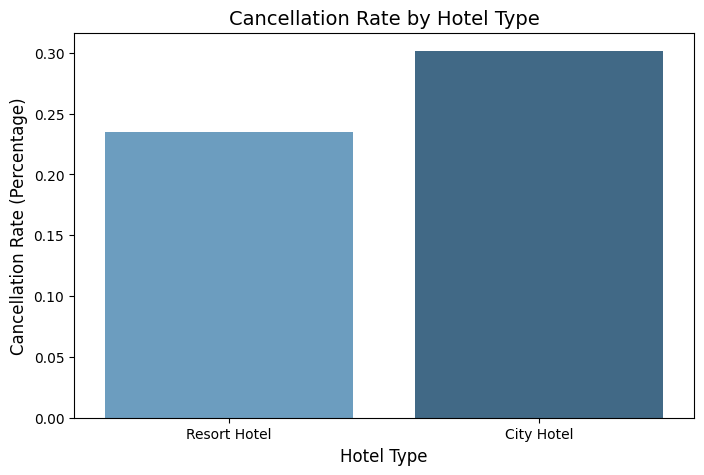

In [312]:
plt.figure(figsize=(8, 5))
# hotel ke hisab se cancellation check karne ke liye barplot
sns.barplot(x='hotel', y='is_canceled', data=df, palette='Blues_d', ci=None)
plt.title('Cancellation Rate by Hotel Type', fontsize=14)
plt.xlabel('Hotel Type', fontsize=12)
plt.ylabel('Cancellation Rate (Percentage)', fontsize=12)
plt.show()

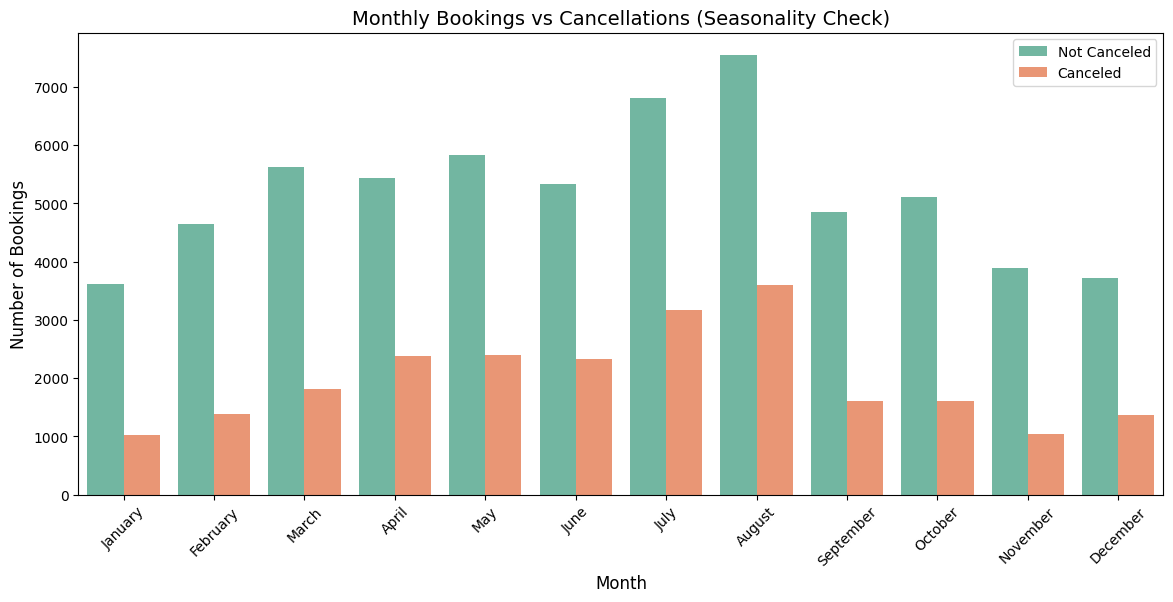

In [313]:
plt.figure(figsize=(14, 6))
# Mahino ke hisab se total bookings aur cancellations ka trend
sns.countplot(x='arrival_date_month', hue='is_canceled', data=df, 
              order=['January', 'February', 'March', 'April', 'May', 'June', 
                     'July', 'August', 'September', 'October', 'November', 'December'],
              palette='Set2')
plt.title('Monthly Bookings vs Cancellations (Seasonality Check)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.xticks(rotation=45)
plt.legend(['Not Canceled', 'Canceled'])
plt.show()

C:\Users\Amir sohail\AppData\Local\Temp\ipykernel_3736\4067975128.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='lead_time', hue='is_canceled', shade=True, palette='bright', common_norm=False)


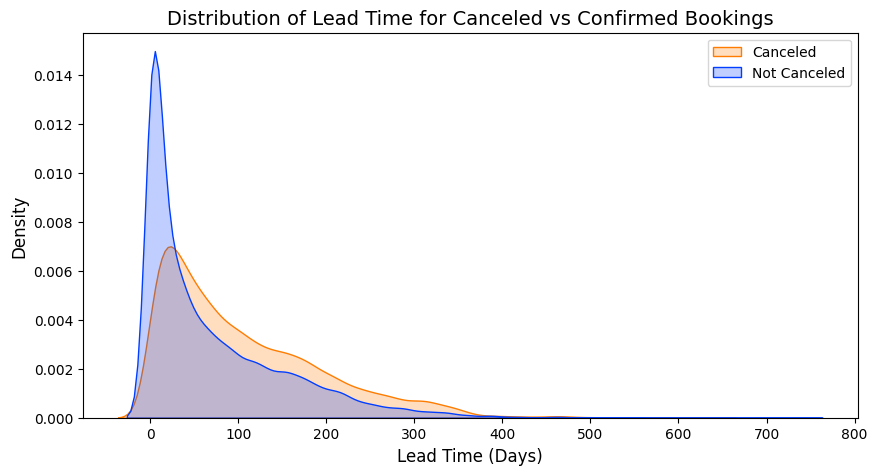

In [314]:
plt.figure(figsize=(10, 5))
# Lead time ki density distribution check karne ke liye
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', shade=True, palette='bright', common_norm=False)
plt.title('Distribution of Lead Time for Canceled vs Confirmed Bookings', fontsize=14)
plt.xlabel('Lead Time (Days)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(['Canceled', 'Not Canceled'])
plt.show()

C:\Users\Amir sohail\AppData\Local\Temp\ipykernel_3736\363648271.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='market_segment', y='adr', data=df[df['adr'] < 500], palette='vlag') # 500 se kam filter kiya taaki outlier clean dikhe


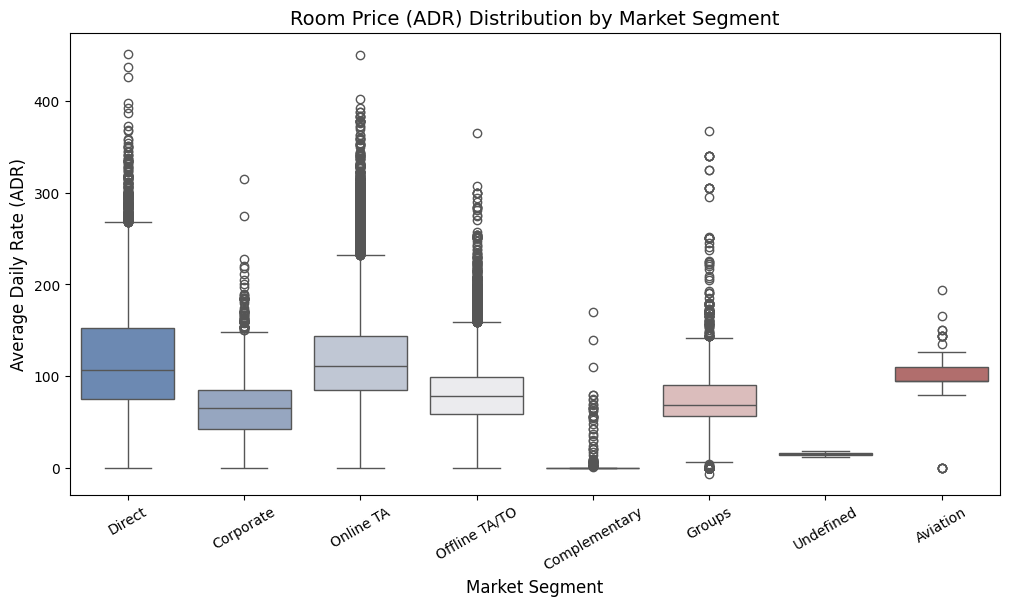

In [315]:
plt.figure(figsize=(12, 6))
# Alag-alag segments ka price distribution dekhne ke liye
sns.boxplot(x='market_segment', y='adr', data=df[df['adr'] < 500], palette='vlag') # 500 se kam filter kiya taaki outlier clean dikhe
plt.title('Room Price (ADR) Distribution by Market Segment', fontsize=14)
plt.xlabel('Market Segment', fontsize=12)
plt.ylabel('Average Daily Rate (ADR)', fontsize=12)
plt.xticks(rotation=30)
plt.show()

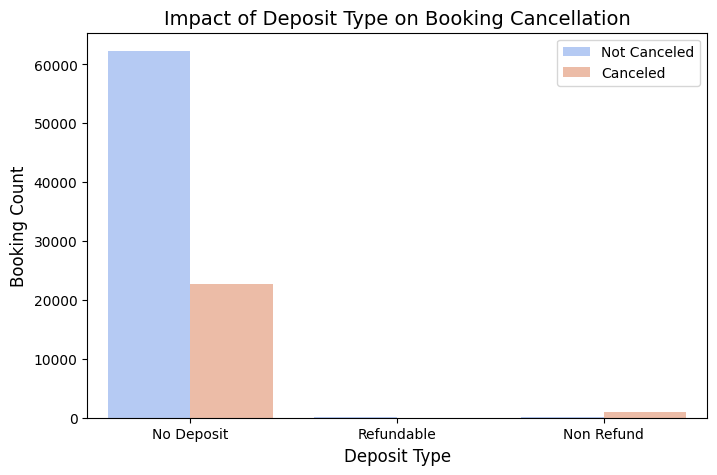

In [316]:
plt.figure(figsize=(8, 5))
# Deposit type ka cancellation par impact
sns.countplot(x='deposit_type', hue='is_canceled', data=df, palette='coolwarm')
plt.title('Impact of Deposit Type on Booking Cancellation', fontsize=14)
plt.xlabel('Deposit Type', fontsize=12)
plt.ylabel('Booking Count', fontsize=12)
plt.legend(['Not Canceled', 'Canceled'])
plt.show()

In [317]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,July,1,0,0,2,0.0,0,...,0,0,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel,0,737,July,1,0,0,2,0.0,0,...,0,0,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel,0,7,July,1,0,1,1,0.0,0,...,0,0,A,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel,0,13,July,1,0,1,1,0.0,0,...,0,0,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel,0,14,July,1,0,2,2,0.0,0,...,0,0,A,0,No Deposit,0,Transient,98.0,0,1


In [318]:
cols = df.columns
for i in cols[3:]:
    print(f"{i} : {df[i].unique()}")

arrival_date_month : ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
arrival_date_day_of_month : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
stays_in_weekend_nights : [ 0  1  2  4  3  6 13  8  5  7 12  9 16 18 19 10 14]
stays_in_week_nights : [ 0  1  2  3  4  5 10 11  8  6  7 15  9 12 33 20 14 16 21 13 30 19 24 40
 22 42 50 25 17 32 26 18 34 35 41]
adults : [ 2  1  3  4 40 26 50 27 55  0 20  6  5 10]
children : [ 0.  1.  2. 10.  3.]
babies : [ 0  1  2 10  9]
meal : ['BB' 'FB' 'HB' 'SC' 'Undefined']
country : ['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' 'Others' 'ROU' 'NOR' 'OMN' 'ARG'
 'POL' 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS'
 'EST' 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX'
 'MAR' 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF'
 'AGO' 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN'
 'JAM' '

In [319]:
# 1. Sabse pehle top 4 sabse zyada aane wali deshon ke naam nikal lo
top_4_countries = df['country'].value_counts().index[:4]

# 2. Ek lambda function chalao: agar desh top 4 mein hai toh wahi rahe, nahi toh 'Other' ho jaye
df['country'] = df['country'].apply(lambda x: x if x in top_4_countries else 'Other')

In [320]:
cat_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'customer_type', 'deposit_type', 'country', 'reserved_room_type']

encoder = OneHotEncoder(sparse_output=False,drop="first",handle_unknown='ignore')
encoded_array = encoder.fit_transform(df[cat_cols])
encoded_col_names = encoder.get_feature_names_out(cat_cols)
df_encoded = pd.DataFrame(encoded_array, columns=encoded_col_names, index=df.index)

df = df.drop(columns=cat_cols)
df = pd.concat([df, df_encoded], axis=1)
df.head()

,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,country_PRT,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P
0,0,342,July,1,0,0,2,0.0,0,0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,737,July,1,0,0,2,0.0,0,0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,7,July,1,0,1,1,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,13,July,1,0,1,1,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,14,July,1,0,2,2,0.0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [321]:
# Ek dictionary banao jisme mahino ka sahi order ho
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 
    'May': 5, 'June': 6, 'July': 7, 'August': 8, 
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

# Ab ise month wale column par apply kar do
df['arrival_date_month'] = df['arrival_date_month'].map(month_map)

In [322]:
numerical_cols = [
    'lead_time',
    'stays_in_weekend_nights',
    'stays_in_week_nights',
    'adults',
    'children',                     # Iska null value aapne abhi fix kiya hai 👍
    'babies',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'booking_changes',
    'days_in_waiting_list',
    'adr',                          # Average Daily Rate (Room Price)
    'required_car_parking_spaces',
    'total_of_special_requests'
]

for col in numerical_cols:
    print(f"{col} : {df[col].unique()}")

lead_time : [342 737   7  13  14   0   9  85  75  23  35  68  18  37  12  72 127  78
  48  60  77  99 118  95  96  69  45  40  15  36  43  70  16 107  47 113
  90  50  93  76   3   1  10   5  17  51  71  63  62 101   2  81 368 364
 324  79  21 109 102   4  98  92  26  73 115  86  52  29  30  33  32   8
 100  44  80  97  64  39  34  27  82  94 110 111  84  66 104  28 258 112
  65  67  55  88  54 292  83 105 280 394  24 103 366 249  22  91  11 108
 106  31  87  41 304 117  59  53  58 116  42 321  38  56  49 317   6  57
  19  25 315 123  46  89  61 312 299 130  74 298 119  20 286 136 129 124
 327 131 460 140 114 139 122 137 126 120 128 135 150 143 151 132 125 157
 147 138 156 164 346 159 160 161 333 381 149 154 297 163 314 155 323 340
 356 142 328 144 336 248 302 175 344 382 146 170 166 338 167 310 148 165
 172 171 145 121 178 305 173 152 354 347 158 185 349 183 352 177 200 192
 361 207 174 330 134 350 334 283 153 197 133 241 193 235 194 261 260 216
 169 209 238 215 141 189 187 223 284 21

In [323]:
scaler = StandardScaler()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,is_canceled,lead_time,arrival_date_month,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,country_PRT,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,reserved_room_type_P
0,0,3.073198,7,1,-0.977153,-1.279255,0.193308,-0.306084,-0.095879,0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,7.693184,7,1,-0.977153,-1.279255,0.193308,-0.306084,-0.095879,0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,-0.845018,7,1,-0.977153,-0.793426,-1.400323,-0.306084,-0.095879,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,-0.774841,7,1,-0.977153,-0.793426,-1.400323,-0.306084,-0.095879,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,-0.763145,7,1,-0.977153,-0.307597,0.193308,-0.306084,-0.095879,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [324]:
df["arrival_date_month"].unique()

array([ 7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6])

In [325]:
X = df.drop(["is_canceled"], axis=1)
y = df["is_canceled"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

rec.array([(0,  3.07319822, 7,  1, -0.9771525, -1.27925458,  0.19330751, -0.30608355, -0.09587944, 0, -0.08230307, -0.10696749,  3.73901034, -0.06958077, -1.93222977, -0.30119447, -0.84593089, 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.),
           (0,  7.69318421, 7,  1, -0.9771525, -1.27925458,  0.19330751, -0.30608355, -0.09587944, 0, -0.08230307, -0.10696749,  5.10963966, -0.06958077, -1.93222977, -0.30119447, -0.84593089, 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.),
           (0, -0.84501775, 7,  1, -0.9771525, -0.79342578, -1.40032287, -0.30608355, -0.09587944, 0, -0.08230307, -0.10696749, -0.37287764, -0.06958077, -0.5731655 , -0.30119447, -0.84593089, 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.),
          

In [327]:
models = {
    "logistic_regression": LogisticRegression(),
    "Decision_tree": DecisionTreeClassifier(),
    "knn": KNeighborsClassifier(),
    "AdaBoostClassifier": AdaBoostClassifier(),
    "XGBClassifier": XGBClassifier(),
    "GradientBoostingClassifier": GradientBoostingClassifier(),
    "RandomForestClassifier": RandomForestClassifier()
}

In [332]:
results = []

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    results.append({
        'model':name,
        'accuracy':accuracy_score(y_test,y_pred)
    })



C:\Users\Amir sohail\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [333]:
results

[{'model': 'logistic_regression', 'accuracy': 0.779842080817464},
 {'model': 'Decision_tree', 'accuracy': 0.7754296330701347},
 {'model': 'knn', 'accuracy': 0.772178355782629},
 {'model': 'AdaBoostClassifier', 'accuracy': 0.7829191825359962},
 {'model': 'XGBClassifier', 'accuracy': 0.8258824895494659},
 {'model': 'GradientBoostingClassifier', 'accuracy': 0.8111936832326986},
 {'model': 'RandomForestClassifier', 'accuracy': 0.8269856014862982}]

In [334]:
results_DF = pd.DataFrame(results)
results_DF.to_csv('results.csv',index=False)


df_results = pd.read_csv('results.csv')
df_results.head()


,model,accuracy
0,logistic_regression,0.779842
1,Decision_tree,0.775430
2,knn,0.772178
3,AdaBoostClassifier,0.782919
4,XGBClassifier,0.825882


C:\Users\Amir sohail\AppData\Local\Temp\ipykernel_3736\2209247379.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='accuracy', y='model', data=df_sorted, palette='mako', ax=axes[0])
C:\Users\Amir sohail\AppData\Local\Temp\ipykernel_3736\2209247379.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df_sorted['model'], rotation=45, ha='right')
C:\Users\Amir sohail\AppData\Local\Temp\ipykernel_3736\2209247379.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diff_from_top', y='model', data=df_sorted, palette='flare', ax=axes[3])


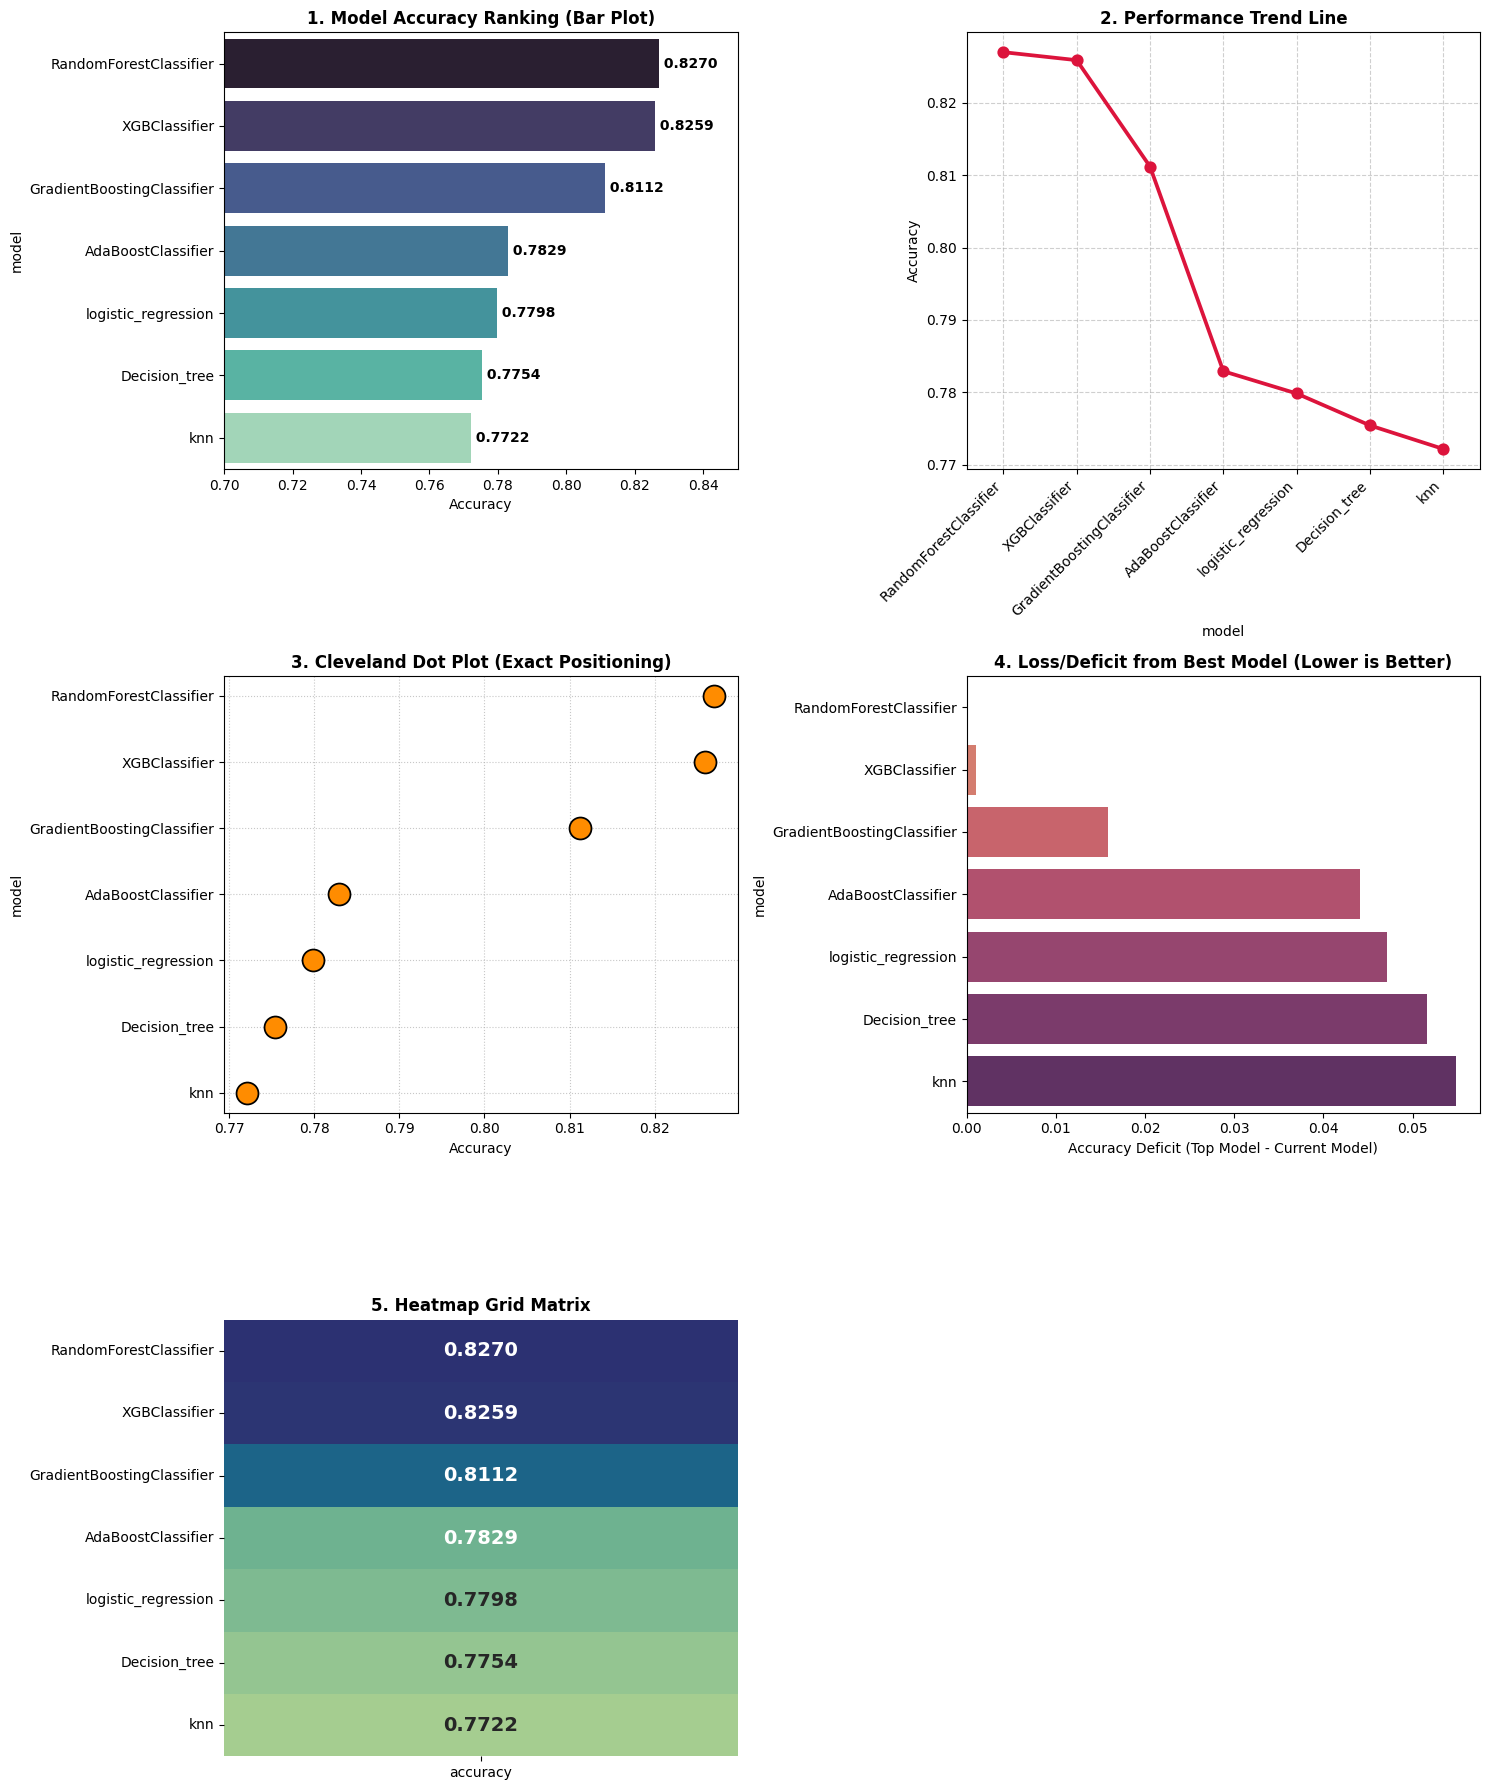

In [335]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sabse pehle results.csv file ko load karo aur sort kar lo
df = pd.read_csv('results.csv')
df_sorted = df.sort_values(by='accuracy', ascending=False).reset_index(drop=True)

# 2. Frame taiyar karo (3 rows, 2 columns ka grid)
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()  # Grid ko 1D array mein badlo taaki index use ho sake

# ---------------------------------------------------------
# PLOT 1: Horizontal Bar Plot (Clean Ranking)
# ---------------------------------------------------------
sns.barplot(x='accuracy', y='model', data=df_sorted, palette='mako', ax=axes[0])
axes[0].set_title('1. Model Accuracy Ranking (Bar Plot)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0.70, 0.85)
# Bars ke upar exact text numbers likhne ke liye loop
for index, value in enumerate(df_sorted['accuracy']):
    axes[0].text(value, index, f' {value:.4f}', va='center', fontweight='bold')

# ---------------------------------------------------------
# PLOT 2: Point Plot (Performance Drop Curve)
# ---------------------------------------------------------
sns.pointplot(x='model', y='accuracy', data=df_sorted, color='crimson', markers='o', ax=axes[1])
axes[1].set_title('2. Performance Trend Line', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(df_sorted['model'], rotation=45, ha='right')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, linestyle='--', alpha=0.6)

# ---------------------------------------------------------
# PLOT 3: Cleveland Dot Plot (Exact Value Positioning)
# ---------------------------------------------------------
sns.scatterplot(x='accuracy', y='model', data=df_sorted, s=250, color='darkorange', marker='o', edgecolor='black', zorder=3, ax=axes[2])
axes[2].set_title('3. Cleveland Dot Plot (Exact Positioning)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Accuracy')
axes[2].grid(True, which='both', linestyle=':', alpha=0.7)

# ---------------------------------------------------------
# PLOT 4: Accuracy Gap/Deficit from Top Model (Lower is Better)
# ---------------------------------------------------------
top_score = df_sorted['accuracy'].max()
df_sorted['diff_from_top'] = top_score - df_sorted['accuracy']

sns.barplot(x='diff_from_top', y='model', data=df_sorted, palette='flare', ax=axes[3])
axes[3].set_title('4. Loss/Deficit from Best Model (Lower is Better)', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Accuracy Deficit (Top Model - Current Model)')

# ---------------------------------------------------------
# PLOT 5: Heatmap Grid Matrix (Exact Numeric Grid)
# ---------------------------------------------------------
df_heatmap = df_sorted[['model', 'accuracy']].set_index('model')
sns.heatmap(df_heatmap, annot=True, fmt='.4f', cmap='crest', cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=axes[4])
axes[4].set_title('5. Heatmap Grid Matrix', fontsize=12, fontweight='bold')
axes[4].set_ylabel('')
axes[4].set_xlabel('')

# ---------------------------------------------------------
# 6th plot khali reh gaya tha, toh use grid se remove kar do
# ---------------------------------------------------------
fig.delaxes(axes[5])

# Layout ko automatic adjust karo aur display/save karo
plt.tight_layout()
plt.show()  # Notebook mein direct plot dekhne ke liye

In [336]:
model_final = RandomForestClassifier()
model_final.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [341]:
y_pred = model_final.predict(X_test)
accuracy_score(y_test, y_pred)

0.8248954946586159

In [342]:
import joblib

joblib.dump(model_final, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']